# **“The formula that killed Wall Street”: Effectiveness of Copulas in Modeling FX Dependence**

## **Mathematical Finance (MATH 86); 26W; Prof. John Welborn**
## **Final Research Project**

### Authors: Klara Drees-Gross, Henry Moore, Stephanie Zoltick
### Contact info: klara.e.drees-gross.26@dartmouth.edu, henry.j.moore.26@dartmouth.edu, stephanie.r.zoltick.26@dartmouth.edu

## **AI Acknowledgement and Sources**

**Disclosure of generative AI use**: We used AI as a tool to clarify concepts in the literature and assist writing code in this Colab notebook. In particular, we used Dartmouth ChatGPT to translate mathematical expressions from the Hurd, Salmon, and Schleicher (2007) paper into implementable Python code that we could run on our new data. We also used it to debug, particularly when we ran into singularity issues during the Bernstein copula quadratic minimization, when the parameters were exploding for time-varying copulas, and when some of the computational loops had unreasonably high runtime. Finally, Chat supported our understanding of some results we obtained and how they compared to the Hurd paper.

We also utilized Claude to guide us through the implementation and analysis of time-varying copulas. We read about time-varying copulas in a slide deck by Patton (2001), and asked Claude to provide code for Patton's correlation recursion for the Gaussian copula, a time-varying Joe-Clayton copula with separate upper and lower tail dependence dynamics, and a time-varying Survival Gumbel copula. We also asked Claude to clarify some of our more perplexing findings: in particular, it suggested an explanation for why time-varying dependence parameters did not improve triangular consistency relative to constant copulas.

All modeling decisions, interpretations of results, and final conclusions were  validated and verified by our group. ChatGPT and Claude did not generate empirical results or conduct independent analysis; we used these tools as programming and conceptual aids.

**References**:
* Hurd, Matthew, et al. “Using Copulas to Construct Bivariate Foreign Exchange Distributions with an Application to the Sterling Exchange Rate Index.” *SSRN Electronic Journal*, 2007, https://doi.org/10.2139/ssrn.676692. Accessed 29 Oct. 2020.
* Patton, Andrew J. “Modelling Time-Varying Exchange Rate Dependence Using the Conditional Copula.” *SSRN Electronic Journal*, 2001, https://doi.org/10.2139/ssrn.275591. Accessed 7 Dec. 2021.
  * Patton's slide deck summarizing the paper above: https://public.econ.duke.edu/~ap172/Patton_copula_pres_jun01.pdf.

**Data source**: We used data from Wharton Research Data Services, Compustat Global. We exported a decade of daily exchange rates to and from USD for various foreign currencies (EUR, JPY, HKD, SGD) between 08/01/2015 and 08/01/2025







## **Contents**

This colab notebook contains three parts.

1. First, we recreate the steps in the Hurd paper for EUR/JPY/USD triplet.

    a. Fit parametric copulas

    b. Test Bernstein copula


2. Then we add time-varying for EUR/JPY/USD triplet.

3. Then we run all the above for HKD/SGD/USD triplet and compare.



## **1. Replicating Hurd et al. methodology on new data**

Our program follows the approach of Hurd et al. (2007), whose methodology builds on the work of Bikos (2000), Taylor and Wang (2004), and Bennett and Kennedy (2004).

### **A. Extracting data, calculating EUR/JPY rate via the Triangular Identity, and verifying no-arbitrage**

This code replicates the first step in Hurd et al.'s methodology, as stated in the following passage:
"We use a similar line of reasoning as Taylor and Wang to derive a relationship between the
density of the euro-dollar exchange rate (denoted by z), under the risk-neutral measure
corresponding to a euro-denominated discount bond, and the bivariate density of the
euro-sterling and the dollar-sterling exchange rates (denoted by x and y, respectively), under the
risk-neutral measure corresponding to a sterling-denominated discount bond. However, we
formulate our problem in return-space rather than in level-space by defining each of the three
exchange rates (x, y, and z) in terms of their log-deviations from the forward rate." (p.12)

In [ ]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, rankdata, norm
from scipy.special import comb
from scipy.optimize import minimize
from google.colab import drive
import os

In [ ]:
# Importing path to my data
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/FX Data Math86"
eur_path = base_path + "/EURtoUSD.csv"
jpy_path = base_path + "/JPYtoUSD.csv"
eur = pd.read_csv(eur_path)
jpy = pd.read_csv(jpy_path)

# Convert date
eur['datadate'] = pd.to_datetime(eur['datadate'])
jpy['datadate'] = pd.to_datetime(jpy['datadate'])

# Keep relevant columns
eur = eur[['datadate', 'exratd_tousd']].rename(
    columns={'exratd_tousd': 'EURUSD'}
)
jpy = jpy[['datadate', 'exratd_fromusd']].rename(
    columns={'exratd_fromusd': 'USDJPY'}
)

# Merge
df = pd.merge(eur, jpy, on='datadate', how='inner')
df = df.sort_values('datadate').reset_index(drop=True)

# Check triangular consistency in the given data
df['EURJPY'] = df['EURUSD'] * df['USDJPY']
df['x'] = np.log(df['EURUSD']).diff()
df['y'] = np.log(df['USDJPY']).diff()
df['z'] = np.log(df['EURJPY']).diff()

df = df.dropna().reset_index(drop=True)
error = np.max(np.abs(df['z'] - (df['x'] + df['y'])))
print("Maximum triangular error in the daily cross-currency rates:", error)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Maximum triangular error in the daily cross-currency rates: 1.4988010832439613e-15


In [ ]:
# We need to transform each variable to its uniform marginal distribution

# Extract returns
x = df['x'].values
y = df['y'].values
n = len(x)

# Empirical CDF using ranks
u = rankdata(x) / (n + 1)
v = rankdata(y) / (n + 1)
df['u'] = u
df['v'] = v
df[['u','v']].head()

,u,v
0,0.503969,0.489461
1,0.044621,0.665480
2,0.280044,0.331235
3,0.022721,0.960854
4,0.896250,0.197646


### **B. Gaussian Copula**

Gaussian Copula L2 error (%): 42.70605988504762


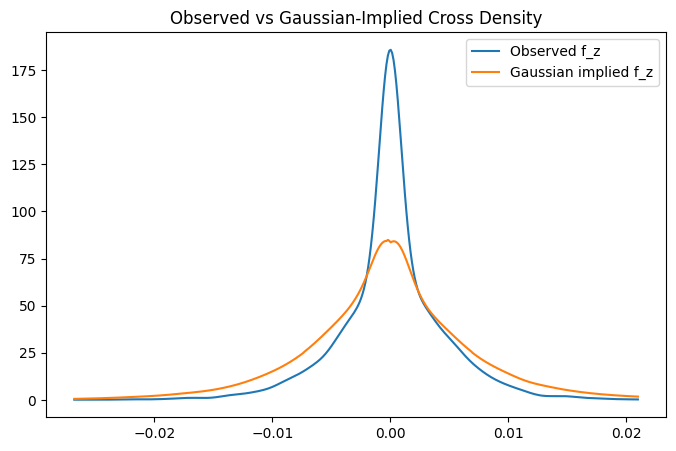

In [ ]:
# Avoid exact 0/1 values
eps = 1e-6
u_adj = np.clip(df['u'].values, eps, 1-eps)
v_adj = np.clip(df['v'].values, eps, 1-eps)

# Transform to normal quantiles
z1 = norm.ppf(u_adj)
z2 = norm.ppf(v_adj)

# Marginal returns
x_vals = df['x'].values
y_vals = df['y'].values
z_vals = df['z'].values

kde_x = gaussian_kde(x_vals)
kde_y = gaussian_kde(y_vals)
kde_z = gaussian_kde(z_vals)

# Empirical CDF
def empirical_cdf(sample):
    sorted_sample = np.sort(sample)
    n = len(sample)
    def cdf_func(x):
        return np.searchsorted(sorted_sample, x, side='right') / n
    return np.vectorize(cdf_func)

F_x = empirical_cdf(x_vals)
F_y = empirical_cdf(y_vals)

# Gaussian Copula Density
def gaussian_copula_density(u, v, rho):
    z1 = norm.ppf(u)
    z2 = norm.ppf(v)
    denom = np.sqrt(1 - rho**2)
    exponent = (
        (z1**2 + z2**2)/2
        - (z1**2 - 2*rho*z1*z2 + z2**2)/(2*(1 - rho**2))
    )
    return (1/denom) * np.exp(exponent)

# Implied probability density function for the cross-rate return
# z, at a specific value s, given the correlation parameter rho
# of a Gaussian copula
def implied_fz(s, rho):
    # Integration grid over u
    u_grid = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_grid)
    fy_u_minus_s = kde_y(u_grid - s)
    Fx_u = F_x(u_grid)
    Fy_u_minus_s = F_y(u_grid - s)

    # Avoid 0/1 problems
    eps = 1e-6
    Fx_u = np.clip(Fx_u, eps, 1-eps)
    Fy_u_minus_s = np.clip(Fy_u_minus_s, eps, 1-eps)
    copula_vals = gaussian_copula_density(Fx_u, Fy_u_minus_s, rho)
    integrand = copula_vals * fx_u * fy_u_minus_s * np.exp(-u_grid)
    return np.trapezoid(integrand, u_grid)

# wider support + higher resolution
rho_hat = np.corrcoef(z1, z2)[0,1]
s_min = np.percentile(z_vals, 0.1)
s_max = np.percentile(z_vals, 99.9)
s_grid = np.linspace(s_min, s_max, 400)

implied_density = np.array([implied_fz(s, rho_hat) for s in s_grid])
observed_density = kde_z(s_grid)

# Calculate L2 error
def L2_percent(observed, implied, grid):
    num = np.trapezoid((observed - implied)**2, grid)
    den = np.trapezoid(observed**2, grid)
    return np.sqrt(num / den) * 100

print("Gaussian Copula L2 error (%):", L2_percent(observed_density, implied_density, s_grid))

# Plot figure
plt.figure(figsize=(8,5))
plt.plot(s_grid, observed_density, label="Observed f_z")
plt.plot(s_grid, implied_density, label="Gaussian implied f_z")
plt.legend()
plt.title("Observed vs Gaussian-Implied Cross Density")
plt.show()

### **C. Gumbel Copula**

/tmp/ipykernel_41527/1223711172.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz((observed_density - implied)**2, s_grid)


Estimated Gumbel theta: 1.001
Gumbel L2 (%): 88.31836172368564


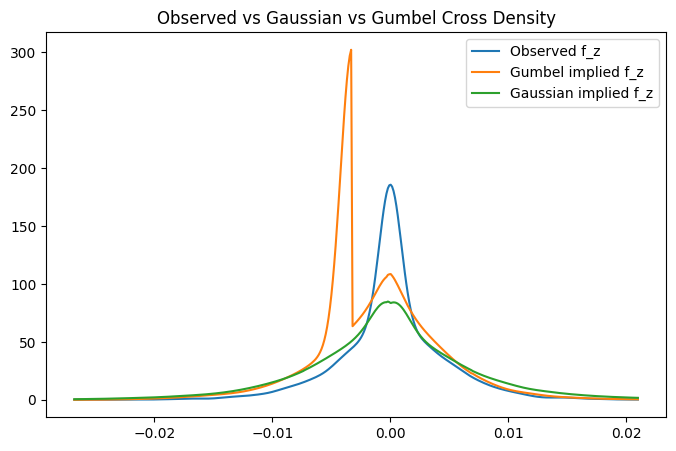

1.001
If θ ≈ 1.001 → optimizer is hitting boundary.
That confirms this copula is not a good fit


In [ ]:
# Gumbel copula density
def gumbel_copula_density(u, v, theta):
    # prevent log(0)
    eps = 1e-6
    u = np.clip(u, eps, 1-eps)
    v = np.clip(v, eps, 1-eps)
    log_u = -np.log(u)
    log_v = -np.log(v)

    A = log_u**theta + log_v**theta
    C = np.exp(-A**(1/theta))

    part1 = C / (u * v)
    part2 = (log_u * log_v)**(theta-1)
    part3 = A**(2 - 1/theta)
    part4 = 1 + (theta-1) * A**(-1/theta)

    return part1 * part2 / part3 * part4

# Implied probability density function for the cross-rate return
# z, at a specific value s, given the correlation parameter theta
# of a Gumbel copula
def implied_fz_gumbel(s, theta):
    u_grid = np.linspace(np.min(x_vals), np.max(x_vals), 400)

    fx_u = kde_x(u_grid)
    fy_u_minus_s = kde_y(u_grid - s)

    Fx_u = F_x(u_grid)
    Fy_u_minus_s = F_y(u_grid - s)

    eps = 1e-6
    Fx_u = np.clip(Fx_u, eps, 1-eps)
    Fy_u_minus_s = np.clip(Fy_u_minus_s, eps, 1-eps)

    copula_vals = gumbel_copula_density(Fx_u, Fy_u_minus_s, theta)
    integrand = copula_vals * fx_u * fy_u_minus_s * np.exp(-u_grid)

    return np.trapezoid(integrand, u_grid)

# Find theta that minimizes the L2 distance between the
# observed density and the denzity predicted by the model
from scipy.optimize import minimize
def L2_gumbel(theta):
    theta = theta[0]
    if theta < 1:
        return 1e6
    implied = np.array([implied_fz_gumbel(s, theta) for s in s_grid])
    return np.trapz((observed_density - implied)**2, s_grid)

result = minimize(L2_gumbel, x0=[1.2], bounds=[(1.001, 10)])
theta_hat = result.x[0]
print("Estimated Gumbel theta:", theta_hat)
implied_gumbel = np.array([implied_fz_gumbel(s, theta_hat) for s in s_grid])

# Calculate L2 error
print("Gumbel L2 (%):", L2_percent(observed_density, implied_gumbel, s_grid))

# Plot figure
plt.figure(figsize=(8,5))
plt.plot(s_grid, observed_density, label="Observed f_z")
plt.plot(s_grid, implied_gumbel, label="Gumbel implied f_z")
plt.plot(s_grid, implied_density, label="Gaussian implied f_z")
plt.legend()
plt.title("Observed vs Gaussian vs Gumbel Cross Density")
plt.show()

# Print theta
print(theta_hat)
print("If θ ≈ 1.001 → optimizer is hitting boundary.")
print("That confirms this copula is not a good fit")

### **D. Survival Gumbel Copula**

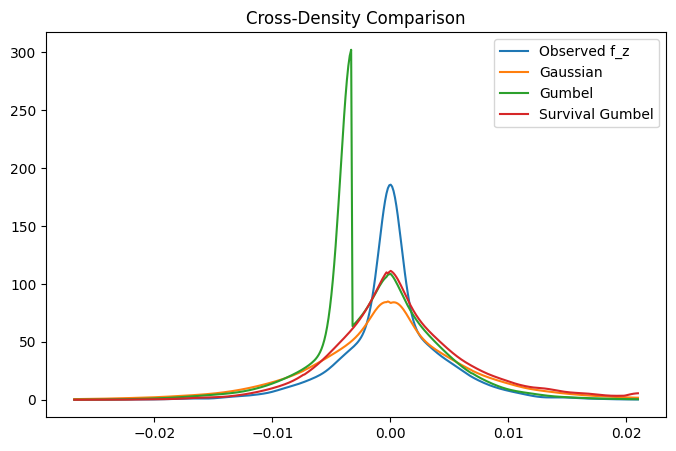

In [ ]:
def survival_gumbel_density(u, v, theta):
    eps = 1e-6
    u = np.clip(u, eps, 1-eps)
    v = np.clip(v, eps, 1-eps)
    return gumbel_copula_density(1-u, 1-v, theta)

def implied_fz_survival_gumbel(s, theta):
    u_grid = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_grid)
    fy_u_minus_s = kde_y(u_grid - s)

    Fx_u = F_x(u_grid)
    Fy_u_minus_s = F_y(u_grid - s)
    eps = 1e-6
    Fx_u = np.clip(Fx_u, eps, 1-eps)
    Fy_u_minus_s = np.clip(Fy_u_minus_s, eps, 1-eps)

    copula_vals = survival_gumbel_density(Fx_u, Fy_u_minus_s, theta)
    integrand = copula_vals * fx_u * fy_u_minus_s * np.exp(-u_grid)
    return np.trapezoid(integrand, u_grid)

def L2_survival_gumbel(theta):
    theta = theta[0]
    if theta < 1:
        return 1e6
    implied = np.array([
        implied_fz_survival_gumbel(s, theta)
        for s in s_grid
    ])
    return np.trapezoid((observed_density - implied)**2, s_grid)
result_sg = minimize(
    L2_survival_gumbel,
    x0=[1.5],
    bounds=[(1.001, 10)]
)
theta_sg = result_sg.x[0]

implied_sg = np.array([
    implied_fz_survival_gumbel(s, theta_sg)
    for s in s_grid
])
L2_sg_error = np.sqrt(
    np.trapezoid((observed_density - implied_sg)**2, s_grid)
)

plt.figure(figsize=(8,5))
plt.plot(s_grid, observed_density, label="Observed f_z")
plt.plot(s_grid, implied_density, label="Gaussian")
plt.plot(s_grid, implied_gumbel, label="Gumbel")
plt.plot(s_grid, implied_sg, label="Survival Gumbel")
plt.legend()
plt.title("Cross-Density Comparison")
plt.show()

### **E. Non-Parametric Copula: Bernstein**

Similarly to our findings, Hurd et al. achieved L2 distances of 27% or above for parametric copulas. Given this large error, they looked for a copula that could better capture the dependence structure between FX rates:

"One very desirable property of the Bernstein copula is its ability to approximate
any possible copula function. We refer the reader to Appendix B for a more detailed description of
the Bernstein copula as well as an efficient way to fit it to a given set of triangular marginal
distributions.

The results of our application of the Bernstein copula to the euro-dollar distributions for 23 July
2004 and 18 December 2002 are shown in the bottom sections of Tables A and B. We use
approximations with Bernstein polynomials of order 2 to 11 and find that for both dates the L
2
goodness-of-fit criterion improves quickly and that an 11th order expansion provides a fit which is
dramatically better than that of the parametric and perturbed normal copulas."
(p. 18)


Running Bernstein with m = 2


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_trustregion_constr/equality_constrained_sqp.py:81: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_trustregion_constr/equality_constrained_sqp.py:217: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)


Bernstein(2) L2 (%): 36.7841

Running Bernstein with m = 5
Bernstein(5) L2 (%): 16.2887

Running Bernstein with m = 7
Bernstein(7) L2 (%): 27.2976

Running Bernstein with m = 9
Bernstein(9) L2 (%): 23.1511

Running Bernstein with m = 11
Bernstein(11) L2 (%): 12.5906


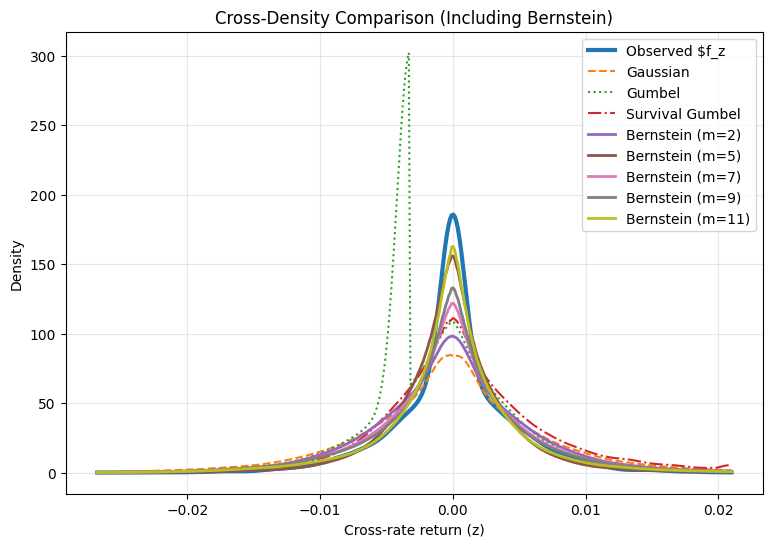

In [ ]:
def bernstein_poly(j, m, x):
    return comb(m, j) * (x**j) * ((1-x)**(m-j))

def compute_psi(m):
    # Wider integration grid
    u_min = np.percentile(x_vals, 0.1)
    u_max = np.percentile(x_vals, 99.9)
    u_grid = np.linspace(u_min, u_max, 500)

    psi = np.zeros((m, m, len(s_grid)))

    Fx_u = np.clip(F_x(u_grid), 1e-8, 1-1e-8)
    fx_u = kde_x(u_grid)

    for i, s in enumerate(s_grid):

        Fy_us = np.clip(F_y(u_grid - s), 1e-8, 1-1e-8)
        fy_us = kde_y(u_grid - s)

        for k in range(m):
            Pk = bernstein_poly(k, m-1, Fx_u)

            for l in range(m):
                Pl = bernstein_poly(l, m-1, Fy_us)

                integrand = (
                    m**2 *
                    Pk * Pl *
                    fx_u * fy_us *
                    np.exp(-u_grid)
                )

                psi[k,l,i] = np.trapezoid(integrand, u_grid)
    return psi

# Plot other copulas
plt.figure(figsize=(9,6))

plt.plot(s_grid, observed_density,
         label="Observed $f_z",
         linewidth=3)

plt.plot(s_grid, implied_density,
         label="Gaussian",
         linestyle="--")

plt.plot(s_grid, implied_gumbel,
         label="Gumbel",
         linestyle=":")

plt.plot(s_grid, implied_sg,
         label="Survival Gumbel",
         linestyle="-.")

# Orders of Bernstein
m_list = [2, 5, 7, 9, 11]
results = {}

# For each order
for m in m_list:
    print(f"\nRunning Bernstein with m = {m}")

    psi = compute_psi(m)
    psi_flat = psi.reshape(m*m, len(s_grid))

    H = np.zeros((m*m, m*m))
    g = np.zeros(m*m)

    for i in range(m*m):
        for j in range(m*m):
            H[i, j] = np.trapezoid(
                psi_flat[i] * psi_flat[j],
                s_grid
            )
        g[i] = np.trapezoid(
            observed_density * psi_flat[i],
            s_grid
        )

    # Regularization (to avoid singular H)
    lambda_reg = 1e-6
    H_reg = H + lambda_reg * np.eye(m*m)

    # Objective
    def objective(theta):
        return theta @ H_reg @ theta - 2 * g @ theta

    # Constraints (from Hurd)
    bounds = [(0, None)] * (m*m)
    constraints = []

    # Row sums = 1/m
    for k in range(m):
        def row_constraint(theta, k=k):
            return np.sum(theta[k*m:(k+1)*m]) - 1/m
        constraints.append({'type': 'eq', 'fun': row_constraint})

    # Column sums = 1/m
    for l in range(m):
        def col_constraint(theta, l=l):
            return np.sum(theta[l::m]) - 1/m
        constraints.append({'type': 'eq', 'fun': col_constraint})

    theta0 = np.ones(m*m) / (m*m)

    result = minimize(
        objective,
        theta0,
        method='trust-constr',
        bounds=bounds,
        constraints=constraints
    )

    theta_hat = result.x

    implied_bernstein = theta_hat @ psi_flat

    num = np.trapezoid(
        (observed_density - implied_bernstein)**2,
        s_grid
    )
    den = np.trapezoid(
        observed_density**2,
        s_grid
    )

    # Print L2
    current_l2_score = np.sqrt(num / den) * 100
    results[m] = current_l2_score
    print(f"Bernstein({m}) L2 (%): {current_l2_score:.4f}")

    # Plot line
    plt.plot(s_grid, implied_bernstein,
         label=f"Bernstein (m={m})",
         linewidth=2)

plt.legend()
plt.title("Cross-Density Comparison (Including Bernstein)")
plt.xlabel("Cross-rate return (z)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

## **2. Extending with Time-Variation**

Up unti now, we've fitted copulas to EUR/USD and USD/JPY returns to model their joint dependence, and have checked how well the implied distribution matches the observed EUR/JPY cross-rate density. A closer match indicates greater consistency with triangular no-arbitrage.

We then asked ourselves if allowing the dependence parameter to change over time would improve our match to the observed data. In other words, does changing the model's dependence structure between the two currency pairs over time better reproduce the cross-rate density than a fixed parameter?

Since we hadn't worked with time-varying copulas before, we read Patton's "Modelling Time-Varying Exchange Rate Dependence using the Conditional Copula" (2001) slides, and asked Claude to assist in implementing these formulas for our data.

### **A. Rolling-Window Estimate of Time-Varying Gaussian Correlation**

This code block re-estimates the Gaussian correlation parameter p every day using the last 60 observations. We do this to verify our hypothesis that the dependence between currencies is varying and not constant over time.

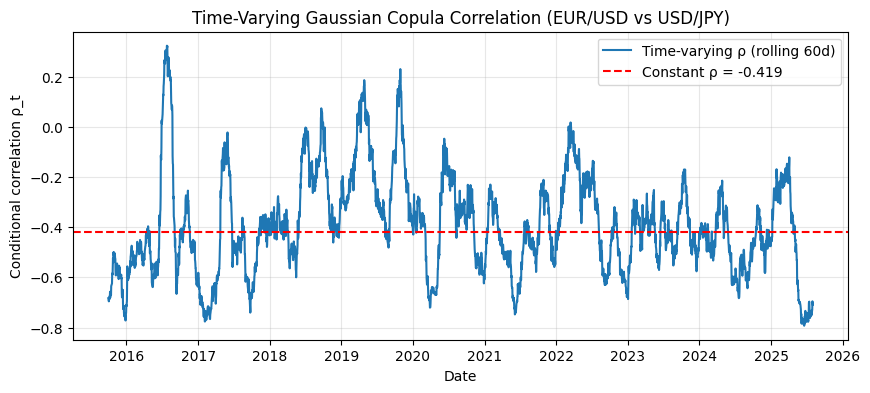

In [ ]:
# Time-Varying Gaussian Copula: Rolling Window Correlation
window = 60  # ~3 months of trading days

eps = 1e-6
u_adj = np.clip(df['u'].values, eps, 1-eps)
v_adj = np.clip(df['v'].values, eps, 1-eps)

z1 = norm.ppf(u_adj)
z2 = norm.ppf(v_adj)

# Rolling Pearson correlation on normal-space transforms
rho_tv = np.full(len(df), np.nan)
for t in range(window, len(df)):
    rho_tv[t] = np.corrcoef(z1[t-window:t], z2[t-window:t])[0, 1]

df['rho_tv'] = rho_tv

plt.figure(figsize=(10, 4))
plt.plot(df['datadate'], df['rho_tv'], label='Time-varying ρ (rolling 60d)')
plt.axhline(rho_hat, color='red', linestyle='--', label=f'Constant ρ = {rho_hat:.3f}')
plt.title('Time-Varying Gaussian Copula Correlation (EUR/USD vs USD/JPY)')
plt.xlabel('Date')
plt.ylabel('Conditional correlation ρ_t')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **B. Patton's ARMA-style Recursion**


This is the Autoregressive Moving Average (ARMA) time-varying model that Claude helped us implement based on Patton's lecture slides. Instead of re-estimating p from scratch in each window, the model assumes ρ_t evolves smoothly as a function of two parameters: α (reacivity -- how reactive today's dependence is to the dependence over the last 10 days) and β (persistence -- how slowly the dependece mean-reverts). This is analogous to how GARCH works, but applied to dependence rather than volatility.


Patton TV Normal Copula — ω=-0.3765, β=1.0000, α=0.2472


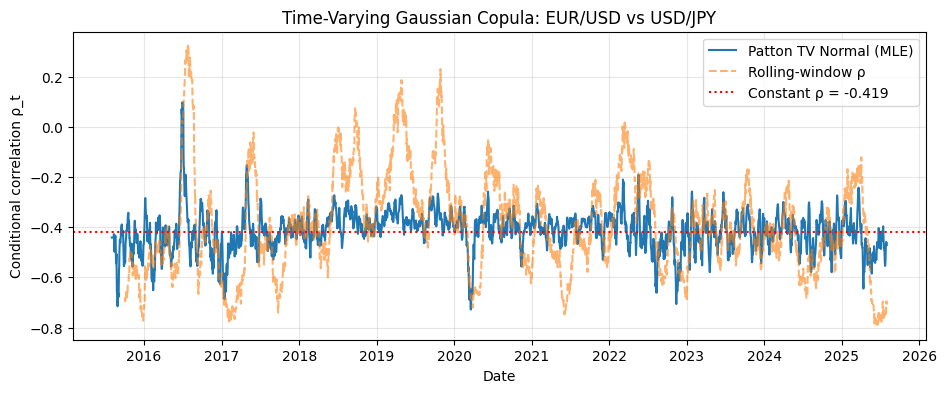

In [ ]:
# Patton's (2001) GARCH-Style Evolution Equation for ρ
# ρ_t = Λ̃(ω + β·ρ_{t-1} + α · (1/10) Σ Φ^{-1}(u_{t-j})·Φ^{-1}(v_{t-j}))
# where Λ̃ is the modified logistic: (1-e^{-x})/(1+e^{-x}) maps to (-1, 1)

def modified_logistic(x):
    # Maps R -> (-1, 1), used for correlation parameter.
    return (1 - np.exp(-x)) / (1 + np.exp(-x))

def patton_rho_path(params, z1, z2, lag=10):
    # Compute the time-varying rho path from Patton's recursion.
    omega, beta, alpha = params
    T = len(z1)
    rho = np.zeros(T)
    rho[:lag] = np.corrcoef(z1[:lag], z2[:lag])[0, 1]  # initialize
    for t in range(lag, T):
        forcing = np.mean(z1[t-lag:t] * z2[t-lag:t])
        rho[t] = modified_logistic(omega + beta * rho[t-1] + alpha * forcing)
    return rho

def neg_log_likelihood_tv_normal(params, z1, z2, lag=10):
    # Negative log-likelihood for time-varying normal copula.
    omega, beta, alpha = params
    if abs(beta) >= 1:
        return 1e9
    rho = patton_rho_path(params, z1, z2, lag)
    T = len(z1)
    ll = 0.0
    for t in range(lag, T):
        r = rho[t]
        if abs(r) >= 1:
            return 1e9
        # Gaussian copula log-density
        ll += (
            -0.5 * np.log(1 - r**2)
            - (r**2 * (z1[t]**2 + z2[t]**2) - 2*r*z1[t]*z2[t])
            / (2 * (1 - r**2))
        )
    return -ll

result_tv = minimize(
    neg_log_likelihood_tv_normal,
    x0=[0.01, 0.95, 0.05],
    args=(z1, z2),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6}
)

omega_hat, beta_hat, alpha_hat = result_tv.x
print(f"Patton TV Normal Copula — ω={omega_hat:.4f}, β={beta_hat:.4f}, α={alpha_hat:.4f}")

rho_patton = patton_rho_path(result_tv.x, z1, z2)
df['rho_patton'] = rho_patton

# Plot Patton ρ_t vs. Constant vs. Rolling
plt.figure(figsize=(11, 4))
plt.plot(df['datadate'], df['rho_patton'], label='Patton TV Normal (MLE)', linewidth=1.5)
plt.plot(df['datadate'], df['rho_tv'], label='Rolling-window ρ', alpha=0.6, linestyle='--')
plt.axhline(rho_hat, color='red', linestyle=':', label=f'Constant ρ = {rho_hat:.3f}')
plt.title('Time-Varying Gaussian Copula: EUR/USD vs USD/JPY')
plt.xlabel('Date')
plt.ylabel('Conditional correlation ρ_t')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **C. Time-Varying Joe-Clayton Copula**

This copula goes further than the previous model by modeling tail dependence separately from overall correlation. Patton writes that "The parameters of the Joe-Clayton copula are strictly increasing functions of the upper and lower tail dependence measures (Joe, 1997)." Each parameter has its own ARMA-style recursion. Hence, this model allows us to test whether crashes and bubbles (lower and upper tails) have different dependence structures over time, which the Gaussian copula (symmetric) and the Gumbel/Survival Gumbel copulas (one-sided asymmetric) cannot capture.

TV Joe-Clayton fitted.
  Upper tail params (ω,β,α): [-3.7663 -0.5013 -1.1908]
  Lower tail params (ω,β,α): [-4.3532 -0.6494 -0.3403]


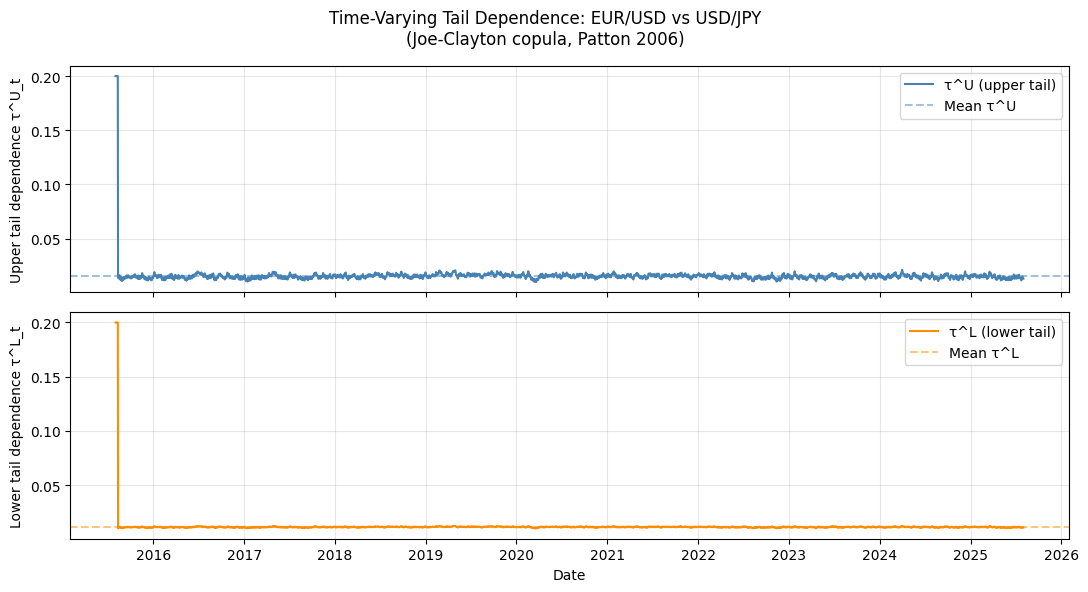

In [ ]:
# Time-Varying Joe-Clayton Copula
# Patton's "Symmetrised Joe-Clayton" (SJC) copula

def logistic(x):
    return 1 / (1 + np.exp(-x))

def joe_clayton_copula_cdf(u, v, tau_U, tau_L):
    # Joe-Clayton (BB7) copula CDF.
    eps = 1e-9
    u = np.clip(u, eps, 1-eps)
    v = np.clip(v, eps, 1-eps)
    # Convert tail dependence params to copula params
    if tau_U <= 0 or tau_U >= 1 or tau_L <= 0 or tau_L >= 1:
        return np.nan
    kappa = 1 / np.log2(2 - tau_U)
    gamma = -1 / np.log2(tau_L)
    A = (1 - (1-u)**kappa)**(-gamma)
    B = (1 - (1-v)**kappa)**(-gamma)
    inner = A + B - 1
    inner = np.maximum(inner, eps)
    return 1 - (1 - inner**(-1/gamma))**(1/kappa)

def joe_clayton_log_density(u, v, tau_U, tau_L):
    # Numerical log-density via finite differences.
    h = 1e-5
    eps = 1e-9
    u = np.clip(u, eps, 1-eps)
    v = np.clip(v, eps, 1-eps)
    c = (
        joe_clayton_copula_cdf(u+h, v+h, tau_U, tau_L)
        - joe_clayton_copula_cdf(u+h, v-h, tau_U, tau_L)
        - joe_clayton_copula_cdf(u-h, v+h, tau_U, tau_L)
        + joe_clayton_copula_cdf(u-h, v-h, tau_U, tau_L)
    ) / (4 * h**2)
    return np.log(np.maximum(c, eps))

def patton_tau_path(params_U, params_L, u, v, lag=10):
    # Compute time paths of τ^U_t and τ^L_t using Patton's forcing variable:
    # forcing_t = (1/lag) * Σ |u_{t-j} - v_{t-j}|
    omega_U, beta_U, alpha_U = params_U
    omega_L, beta_L, alpha_L = params_L
    T = len(u)
    tau_U = np.zeros(T)
    tau_L = np.zeros(T)
    tau_U[:lag] = 0.2
    tau_L[:lag] = 0.2
    for t in range(lag, T):
        forcing = np.mean(np.abs(u[t-lag:t] - v[t-lag:t]))
        tau_U[t] = logistic(omega_U + beta_U * tau_U[t-1] + alpha_U * forcing)
        tau_L[t] = logistic(omega_L + beta_L * tau_L[t-1] + alpha_L * forcing)
    return tau_U, tau_L

def neg_ll_tv_jc(all_params, u, v, lag=10):
    # Negative log-likelihood for time-varying Joe-Clayton copula.
    params_U = all_params[:3]
    params_L = all_params[3:]
    tau_U, tau_L = patton_tau_path(params_U, params_L, u, v, lag)
    T = len(u)
    ll = 0.0
    for t in range(lag, T):
        tU, tL = tau_U[t], tau_L[t]
        if tU <= 0.01 or tU >= 0.99 or tL <= 0.01 or tL >= 0.99:
            return 1e9
        ll += joe_clayton_log_density(u[t], v[t], tU, tL)
    return -ll

# Fit the model
u_vals = df['u'].values
v_vals = df['v'].values
result_jc = minimize(
    neg_ll_tv_jc,
    x0=[-2.0, 4.0, -1.0, -1.5, 4.0, -1.0],
    args=(u_vals, v_vals),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-5, 'fatol': 1e-5}
)
p_U = result_jc.x[:3]
p_L = result_jc.x[3:]
tau_U_path, tau_L_path = patton_tau_path(p_U, p_L, u_vals, v_vals)
df['tau_U'] = tau_U_path
df['tau_L'] = tau_L_path

print("TV Joe-Clayton fitted.")
print(f"  Upper tail params (ω,β,α): {p_U.round(4)}")
print(f"  Lower tail params (ω,β,α): {p_L.round(4)}")

# Plot tail dependence over time
# --> Replicate Patton's tail dependence plot (slide 69)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(df['datadate'], df['tau_U'], color='steelblue', label='τ^U (upper tail)')
ax1.axhline(df['tau_U'][10:].mean(), color='steelblue', linestyle='--', alpha=0.5, label='Mean τ^U')
ax1.set_ylabel('Upper tail dependence τ^U_t')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df['datadate'], df['tau_L'], color='darkorange', label='τ^L (lower tail)')
ax2.axhline(df['tau_L'][10:].mean(), color='darkorange', linestyle='--', alpha=0.5, label='Mean τ^L')
ax2.set_ylabel('Lower tail dependence τ^L_t')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Time-Varying Tail Dependence: EUR/USD vs USD/JPY\n(Joe-Clayton copula, Patton 2001)')
plt.tight_layout()
plt.show()

In [ ]:
# Computing Joe-Clayton L2 score

def tau_to_kappa_gamma(tau_U, tau_L):
    eps = 1e-6
    tau_U = np.clip(tau_U, eps, 1-eps)
    tau_L = np.clip(tau_L, eps, 1-eps)
    kappa = 1 / np.log2(2 - tau_U)
    gamma = -1 / np.log2(tau_L)
    return kappa, gamma

def joe_clayton_density(u, v, tau_U, tau_L):
    return np.exp(joe_clayton_log_density(u, v, tau_U, tau_L))

def implied_fz_tv_jc_fast(s_grid, tau_U_path, tau_L_path, lag=10):
    u_grid = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_grid)
    Fx_u = np.clip(F_x(u_grid), 1e-6, 1-1e-6)
    # drop burn-in
    tau_U_vals = tau_U_path[lag:]
    tau_L_vals = tau_L_path[lag:]
    mask = ~np.isnan(tau_U_vals) & ~np.isnan(tau_L_vals)
    tau_U_vals = tau_U_vals[mask]
    tau_L_vals = tau_L_vals[mask]
    implied_densities = []
    for s in s_grid:
        fy_us = kde_y(u_grid - s)
        Fy_us = np.clip(F_y(u_grid - s), 1e-6, 1-1e-6)
        # Compute average copula density once
        copula_sum = np.zeros(len(u_grid))
        for tU, tL in zip(tau_U_vals, tau_L_vals):
            copula_sum += joe_clayton_density(Fx_u, Fy_us, tU, tL)
        copula_avg = copula_sum / len(tau_U_vals)
        integrand = copula_avg * fx_u * fy_us * np.exp(-u_grid)
        implied_densities.append(np.trapezoid(integrand, u_grid))
    return np.array(implied_densities)

# Print time-varying JC L2
implied_tv_jc = implied_fz_tv_jc(s_grid, tau_U_path, tau_L_path)
print("Time-Varying Joe-Clayton L2 (%):",
      L2_percent(observed_density, implied_tv_jc, s_grid))

# Compare to constant JC
tau_U_const = np.mean(tau_U_path[10:])
tau_L_const = np.mean(tau_L_path[10:])
tau_U_const_path = np.full_like(tau_U_path, tau_U_const)
tau_L_const_path = np.full_like(tau_L_path, tau_L_const)
implied_const_jc = implied_fz_tv_jc(
    s_grid,
    tau_U_const_path,
    tau_L_const_path
)
print("Constant Joe-Clayton L2 (%):",
      L2_percent(observed_density, implied_const_jc, s_grid))

Time-Varying Joe-Clayton L2 (%): 34.17309900526533
Constant Joe-Clayton L2 (%): 34.17298542489363


### **D. Compare L2 Fit for Static vs Time-Varying Models**

**i. Gaussian Copula**

In [ ]:
def implied_fz_tv_gaussian_proper(s_grid, rho_path, lag=10):
    # Average the implied density across all time-varying rho values.
    u_g = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_g)
    Fx_u = np.clip(F_x(u_g), 1e-6, 1-1e-6)
    z1g = norm.ppf(Fx_u)

    rho_vals = rho_path[lag:]
    rho_vals = rho_vals[~np.isnan(rho_vals)]

    implied_densities = []
    for s_val in s_grid:
        fy_us = kde_y(u_g - s_val)
        Fy_us = np.clip(F_y(u_g - s_val), 1e-6, 1-1e-6)
        z2g = norm.ppf(Fy_us)

        # Average the copula density across all rho_t values
        copula_avg = np.zeros(len(u_g))
        for r in rho_vals:
            denom = np.sqrt(1 - r**2)
            exponent = (
                (z1g**2 + z2g**2)/2
                - (z1g**2 - 2*r*z1g*z2g + z2g**2) / (2*(1 - r**2))
            )
            copula_avg += (1/denom) * np.exp(exponent)
        copula_avg /= len(rho_vals)

        integrand = copula_avg * fx_u * fy_us * np.exp(-u_g)
        implied_densities.append(np.trapezoid(integrand, u_g))

    return np.array(implied_densities)

# Compare L2 scores
implied_tv_proper = implied_fz_tv_gaussian_proper(s_grid, rho_patton)
print(f"TV Gaussian L2 (%): {L2_percent(observed_density, implied_tv_proper, s_grid):.4f}")
print(f"Constant Gaussian L2 (%): {L2_percent(observed_density, implied_density, s_grid):.4f}")

TV Gaussian L2 (%): 42.7000
Constant Gaussian L2 (%): 42.7061


We were surprised that time-varying correlation did not improve triangular consistency for this currency trio, contrary to our hypothesis.

An explanation for this is that the L2 test integrates over the entire sample to produce one aggregate density, so if the decade contains periods of high and low correlation, the p_t will balance out and predict an average marginal distribution of z, which resembles the outcome of just using the static mean ρ.

This is consistent with Patton's finding: he notes that while time-varying models worked well with conditioned data, applying them to unconditional density matching was not very different from just using constant copulas.

**ii. Gumbel Copula**

TV Gumbel params (ω, β, α): [-1.3300e-02  2.6581e+00  1.0000e-04]
TV Gumbel L2 (%): 34.6651
Constant Gumbel L2 (%): 88.3184


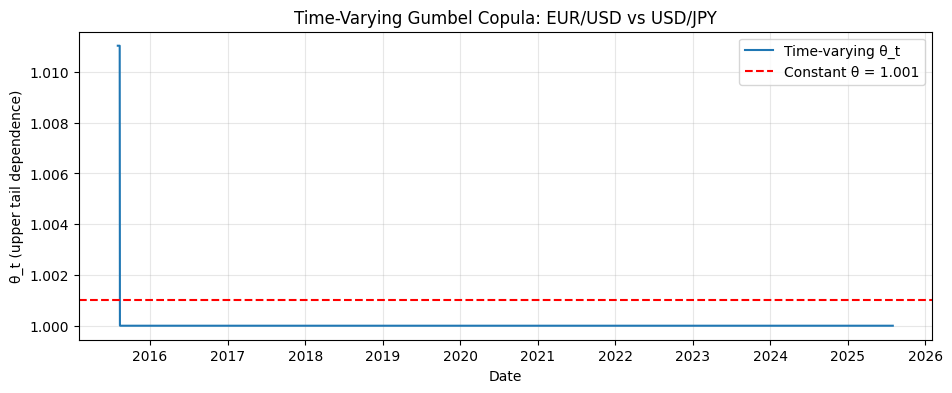

In [ ]:
# Time-Varying Gumbel Copula — Patton-style recursion
# θ_t = Λ(ω + β·θ_{t-1} + α · forcing_t)  where θ ≥ 1
# forcing = mean of |u_{t-j} - v_{t-j}| over last lag days

def logistic_gumbel(x):
    # Maps R -> (1, inf) to keep theta valid for Gumbel.
    return 1 + np.log1p(np.exp(x))  # softplus shift: always > 1

def gumbel_log_density(u, v, theta):
    eps = 1e-6
    u = np.clip(u, eps, 1-eps)
    v = np.clip(v, eps, 1-eps)
    log_u = -np.log(u)
    log_v = -np.log(v)
    A = log_u**theta + log_v**theta
    C = np.exp(-A**(1/theta))
    log_c = (
        np.log(C)
        - np.log(u) - np.log(v)
        + (theta - 1) * np.log(log_u) + (theta - 1) * np.log(log_v)
        - (2 - 1/theta) * np.log(A)
        + np.log(1 + (theta - 1) * A**(-1/theta))
    )
    return log_c

def patton_theta_path(params, u, v, lag=10):
    # Gumbel θ_t evolution.
    omega, beta, alpha = params
    T = len(u)
    theta = np.zeros(T)
    # Extract scalar from whatever form theta_hat is stored as
    theta_init = float(result_sg.x[0]) if hasattr(result_sg, 'x') else float(theta_hat)
    theta[:lag] = theta_init
    for t in range(lag, T):
        forcing = np.mean(np.abs(u[t-lag:t] - v[t-lag:t]))
        prev = max(theta[t-1], 1.0 + 1e-6)  # guard against log(0)
        theta[t] = logistic_gumbel(omega + beta * np.log(prev - 1) + alpha * forcing)
    return theta

def neg_ll_tv_gumbel(params, u, v, lag=10):
    omega, beta, alpha = params
    theta_path = patton_theta_path(params, u, v, lag)
    T = len(u)
    ll = 0.0
    for t in range(lag, T):
        th = theta_path[t]
        if th <= 1.0:
            return 1e9
        ll += gumbel_log_density(u[t], v[t], th)
    return -ll

result_tv_gumbel = minimize(
    neg_ll_tv_gumbel,
    x0=[0.1, 0.85, 0.1],
    args=(u_vals, v_vals),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-5}
)

print("TV Gumbel params (ω, β, α):", result_tv_gumbel.x.round(4))
theta_tv_path = patton_theta_path(result_tv_gumbel.x, u_vals, v_vals)
df['theta_tv'] = theta_tv_path

# Compare L2 scores
def implied_fz_tv_gumbel(s_grid, theta_path, lag=10):
    u_g = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_g)
    Fx_u = np.clip(F_x(u_g), 1e-6, 1-1e-6)
    theta_vals = theta_path[lag:]
    theta_vals = theta_vals[~np.isnan(theta_vals)]
    implied_densities = []
    for s_val in s_grid:
        fy_us = kde_y(u_g - s_val)
        Fy_us = np.clip(F_y(u_g - s_val), 1e-6, 1-1e-6)
        copula_avg = np.zeros(len(u_g))
        for th in theta_vals:
            copula_avg += np.exp(gumbel_log_density(Fx_u, Fy_us, th))
        copula_avg /= len(theta_vals)
        integrand = copula_avg * fx_u * fy_us * np.exp(-u_g)
        implied_densities.append(np.trapezoid(integrand, u_g))
    return np.array(implied_densities)
implied_tv_gumbel = implied_fz_tv_gumbel(s_grid, theta_tv_path)
print(f"TV Gumbel L2 (%): {L2_percent(observed_density, implied_tv_gumbel, s_grid):.4f}")
print(f"Constant Gumbel L2 (%): {L2_percent(observed_density, implied_gumbel, s_grid):.4f}")

# Plot Gumbel
theta_hat = float(result.x[0])  # or result_sg.x[0] for survival Gumbel
plt.figure(figsize=(11, 4))
plt.plot(df['datadate'], df['theta_tv'], label='Time-varying θ_t', linewidth=1.5)
plt.axhline(float(theta_hat), color='red', linestyle='--', label=f'Constant θ = {float(theta_hat):.3f}')
plt.title('Time-Varying Gumbel Copula: EUR/USD vs USD/JPY')
plt.ylabel('θ_t (upper tail dependence)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Interestingly, the L2 score for the time-varying Gumbel is 34.6% -- significantly better than the constant Gumbel (88.3%) and Gaussian (34.7%). This suggests that time time variation is compensating for the structural mismatch (since Gumbel captures upper tail dependence, not lower, as we hypothesized would exhibit a better fit).

**iii. Survival Gumbel Copula**

In [ ]:
def survival_gumbel_log_density(u, v, theta):
    # Log density of survival Gumbel = Gumbel rotated 180 degrees.
    return gumbel_log_density(1-u, 1-v, theta)

def patton_theta_path_sg(params, u, v, lag=10):
    omega, beta, alpha = params
    T = len(u)
    theta = np.zeros(T)
    theta_init = float(theta_sg)  # static Survival Gumbel estimate
    theta[:lag] = theta_init
    for t in range(lag, T):
        forcing = np.mean(np.abs(u[t-lag:t] - v[t-lag:t]))
        prev = max(theta[t-1], 1.0 + 1e-6)
        theta[t] = logistic_gumbel(omega + beta * np.log(prev - 1) + alpha * forcing)
    return theta

def neg_ll_tv_sg(params, u, v, lag=10):
    omega, beta, alpha = params
    theta_path = patton_theta_path_sg(params, u, v, lag)
    T = len(u)
    ll = 0.0
    for t in range(lag, T):
        th = theta_path[t]
        if th <= 1.0:
            return 1e9
        ll += survival_gumbel_log_density(u[t], v[t], th)
    return -ll

result_tv_sg = minimize(
    neg_ll_tv_sg,
    x0=[0.1, 0.85, 0.1],
    args=(u_vals, v_vals),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-5}
)

print("TV Survival Gumbel params (ω, β, α):", result_tv_sg.x.round(4))
theta_tv_sg_path = patton_theta_path_sg(result_tv_sg.x, u_vals, v_vals)
df['theta_tv_sg'] = theta_tv_sg_path

# Compare L2 scores
def implied_fz_tv_sg(s_grid, theta_path, lag=10):
    u_g = np.linspace(np.min(x_vals), np.max(x_vals), 400)
    fx_u = kde_x(u_g)
    Fx_u = np.clip(F_x(u_g), 1e-6, 1-1e-6)
    theta_vals = theta_path[lag:]
    theta_vals = theta_vals[~np.isnan(theta_vals)]
    implied_densities = []
    for s_val in s_grid:
        fy_us = kde_y(u_g - s_val)
        Fy_us = np.clip(F_y(u_g - s_val), 1e-6, 1-1e-6)
        copula_avg = np.zeros(len(u_g))
        for th in theta_vals:
            copula_avg += np.exp(survival_gumbel_log_density(Fx_u, Fy_us, th))
        copula_avg /= len(theta_vals)
        integrand = copula_avg * fx_u * fy_us * np.exp(-u_g)
        implied_densities.append(np.trapezoid(integrand, u_g))
    return np.array(implied_densities)

implied_tv_sg = implied_fz_tv_sg(s_grid, theta_tv_sg_path)
print(f"TV Survival Gumbel L2 (%): {L2_percent(observed_density, implied_tv_sg, s_grid):.4f}")
print(f"Constant Survival Gumbel L2 (%): {L2_percent(observed_density, implied_sg, s_grid):.4f}")

TV Survival Gumbel params (ω, β, α): [-1.3300e-02  2.6581e+00  1.0000e-04]
TV Survival Gumbel L2 (%): 33.6679
Constant Survival Gumbel L2 (%): 33.3775


**iv. Results Summary**

In [ ]:
print("\n--- L2 Scores Summary ---")

# Gaussian Copula
gaussian_l2 = L2_percent(observed_density, implied_density, s_grid)
print(f"Gaussian Copula L2 error (%): {gaussian_l2:.4f}")

# Gumbel Copula
gumbel_l2 = L2_percent(observed_density, implied_gumbel, s_grid)
print(f"Gumbel Copula L2 error (%): {gumbel_l2:.4f}")

# Survival Gumbel Copula
survival_gumbel_l2 = L2_percent(observed_density, implied_sg, s_grid)
print(f"Survival Gumbel Copula L2 error (%): {survival_gumbel_l2:.4f}")

# Bernstein Copulas (assuming 'results' dictionary is available)
if 'results' in globals():
    print("Bernstein Copula L2 errors (%):")
    for m, l2_score in results.items():
        print(f"  Bernstein(m={m}) L2 (%): {l2_score:.4f}")

# Joe-Clayton Copula
if 'implied_tv_jc' in globals():
    implied_const_jc_l2 = L2_percent(observed_density, implied_const_jc, s_grid)
    print(f"Joe-Clayton L2 (%): {implied_const_jc_l2:.4f}")

# Time-Varying Joe-Clayton Copula
if 'implied_tv_jc' in globals():
    implied_tv_jc_l2 = L2_percent(observed_density, implied_tv_jc, s_grid)
    print(f"Time-Varying Joe-Clayton L2 (%): {implied_tv_jc_l2:.4f}")

# Time-Varying Gaussian Copula
if 'implied_tv_proper' in globals():
    tv_gaussian_l2 = L2_percent(observed_density, implied_tv_proper, s_grid)
    print(f"Time-Varying Gaussian L2 (%): {tv_gaussian_l2:.4f}")

# Time-Varying Gumbel Copula
if 'implied_tv_gumbel' in globals():
    tv_gumbel_l2 = L2_percent(observed_density, implied_tv_gumbel, s_grid)
    print(f"Time-Varying Gumbel L2 (%): {tv_gumbel_l2:.4f}")

# Time-Varying Survival Gumbel Copula
if 'implied_tv_sg' in globals():
    tv_survival_gumbel_l2 = L2_percent(observed_density, implied_tv_sg, s_grid)
    print(f"Time-Varying Survival Gumbel L2 (%): {tv_survival_gumbel_l2:.4f}")


--- L2 Scores Summary ---
Gaussian Copula L2 error (%): 42.7061
Gumbel Copula L2 error (%): 88.3184
Survival Gumbel Copula L2 error (%): 33.3775
Bernstein Copula L2 errors (%):
  Bernstein(m=2) L2 (%): 36.7841
  Bernstein(m=5) L2 (%): 16.2887
  Bernstein(m=7) L2 (%): 27.2976
  Bernstein(m=9) L2 (%): 23.1511
  Bernstein(m=11) L2 (%): 12.5906
Joe-Clayton L2 (%): 34.1730
Time-Varying Joe-Clayton L2 (%): 34.1731
Time-Varying Gaussian L2 (%): 42.7000
Time-Varying Gumbel L2 (%): 34.6651
Time-Varying Survival Gumbel L2 (%): 33.6679


### **E. Additional Visualizations**

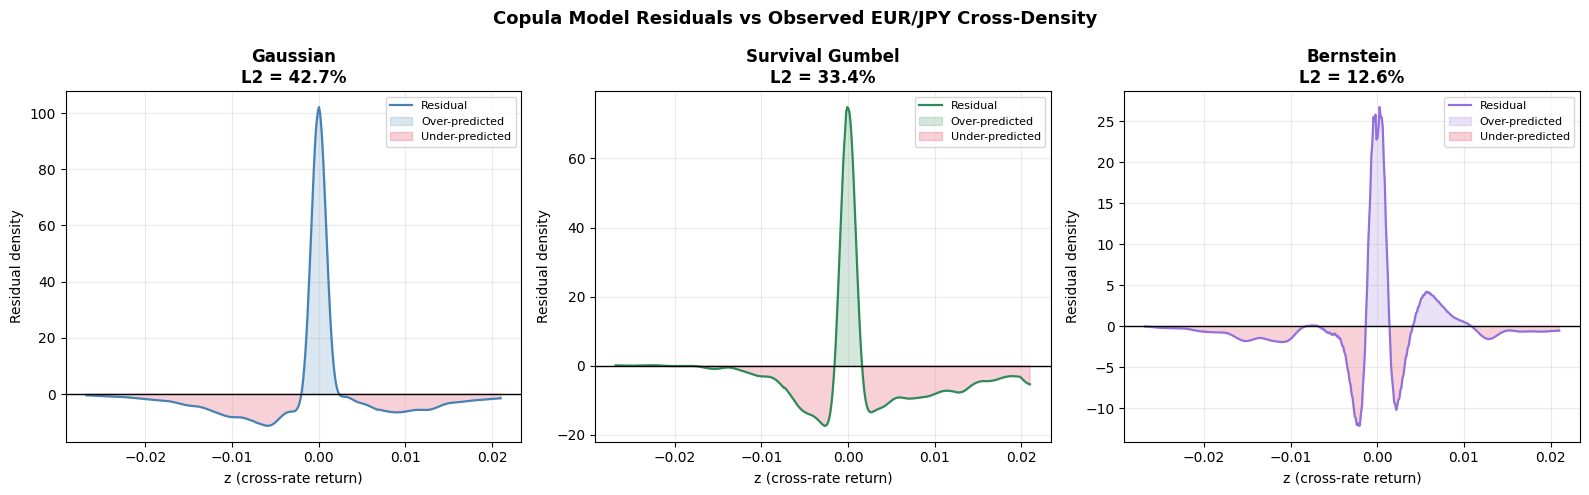

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Copula Model Residuals vs Observed EUR/JPY Cross-Density',
             fontsize=13, fontweight='bold')

model_names   = ['Gaussian', 'Survival Gumbel', 'Bernstein']
implied_list  = [implied_density, implied_sg, implied_bernstein]
colors_res    = ['steelblue', 'seagreen', 'mediumpurple']

for ax, name, imp, col in zip(axes, model_names, implied_list, colors_res):
    residual = observed_density - imp
    ax.plot(s_grid, residual, color=col, linewidth=1.6, label='Residual')
    ax.axhline(0, color='black', linewidth=1.0)
    ax.fill_between(s_grid, residual, 0,
                    where=(residual > 0), alpha=0.2, color=col,
                    label='Over-predicted')
    ax.fill_between(s_grid, residual, 0,
                    where=(residual < 0), alpha=0.2, color='crimson',
                    label='Under-predicted')
    l2 = L2_percent(observed_density, imp, s_grid)
    ax.set_title(f'{name}\nL2 = {l2:.1f}%', fontweight='bold')
    ax.set_xlabel('z (cross-rate return)')
    ax.set_ylabel('Residual density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## **3. Replicating the above on the USD/HKD/SGD triplet**

Because this is a long notebook, we have rerun a copy on the USD/HKD/SGD triplet here: https://colab.research.google.com/drive/15qxr7tp0bFb32nb2dTnuhfR21VcWXgcX?usp=sharing.

For easy reference, we are including the summary of results below:

--- L2 Scores Summary ---

Gaussian Copula L2 error (%): 9.6290

Gumbel Copula L2 error (%): 37.9859

Survival Gumbel Copula L2 error (%): 35.5729

Bernstein Copula L2 errors (%):

  Bernstein(m=2) L2 (%): 6.4801

  Bernstein(m=5) L2 (%): 3.8090

  Bernstein(m=7) L2 (%): 3.9262

  Bernstein(m=9) L2 (%): 1.1556

  Bernstein(m=11) L2 (%): 0.6589

Time-Varying Gaussian L2 (%): 8.3491

Time-Varying Gumbel L2 (%): 37.8233

Time-Varying Survival Gumbel L2 (%): 35.4089